In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('10-diamonds.csv')

In [4]:
df.shape


(53940, 11)

In [5]:
df.head()


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [7]:
df=df.drop('Unnamed: 0', axis=1)

In [8]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [9]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [10]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [11]:
len(df[df["z"]==0]),len(df[df["x"]==0]),len(df[df["y"]==0])

(20, 8, 7)

In [12]:
df=df.drop(df[df["x"]==0].index)
df=df.drop(df[df["y"]==0].index)
df=df.drop(df[df["z"]==0].index)

In [13]:
df.shape

(53920, 10)

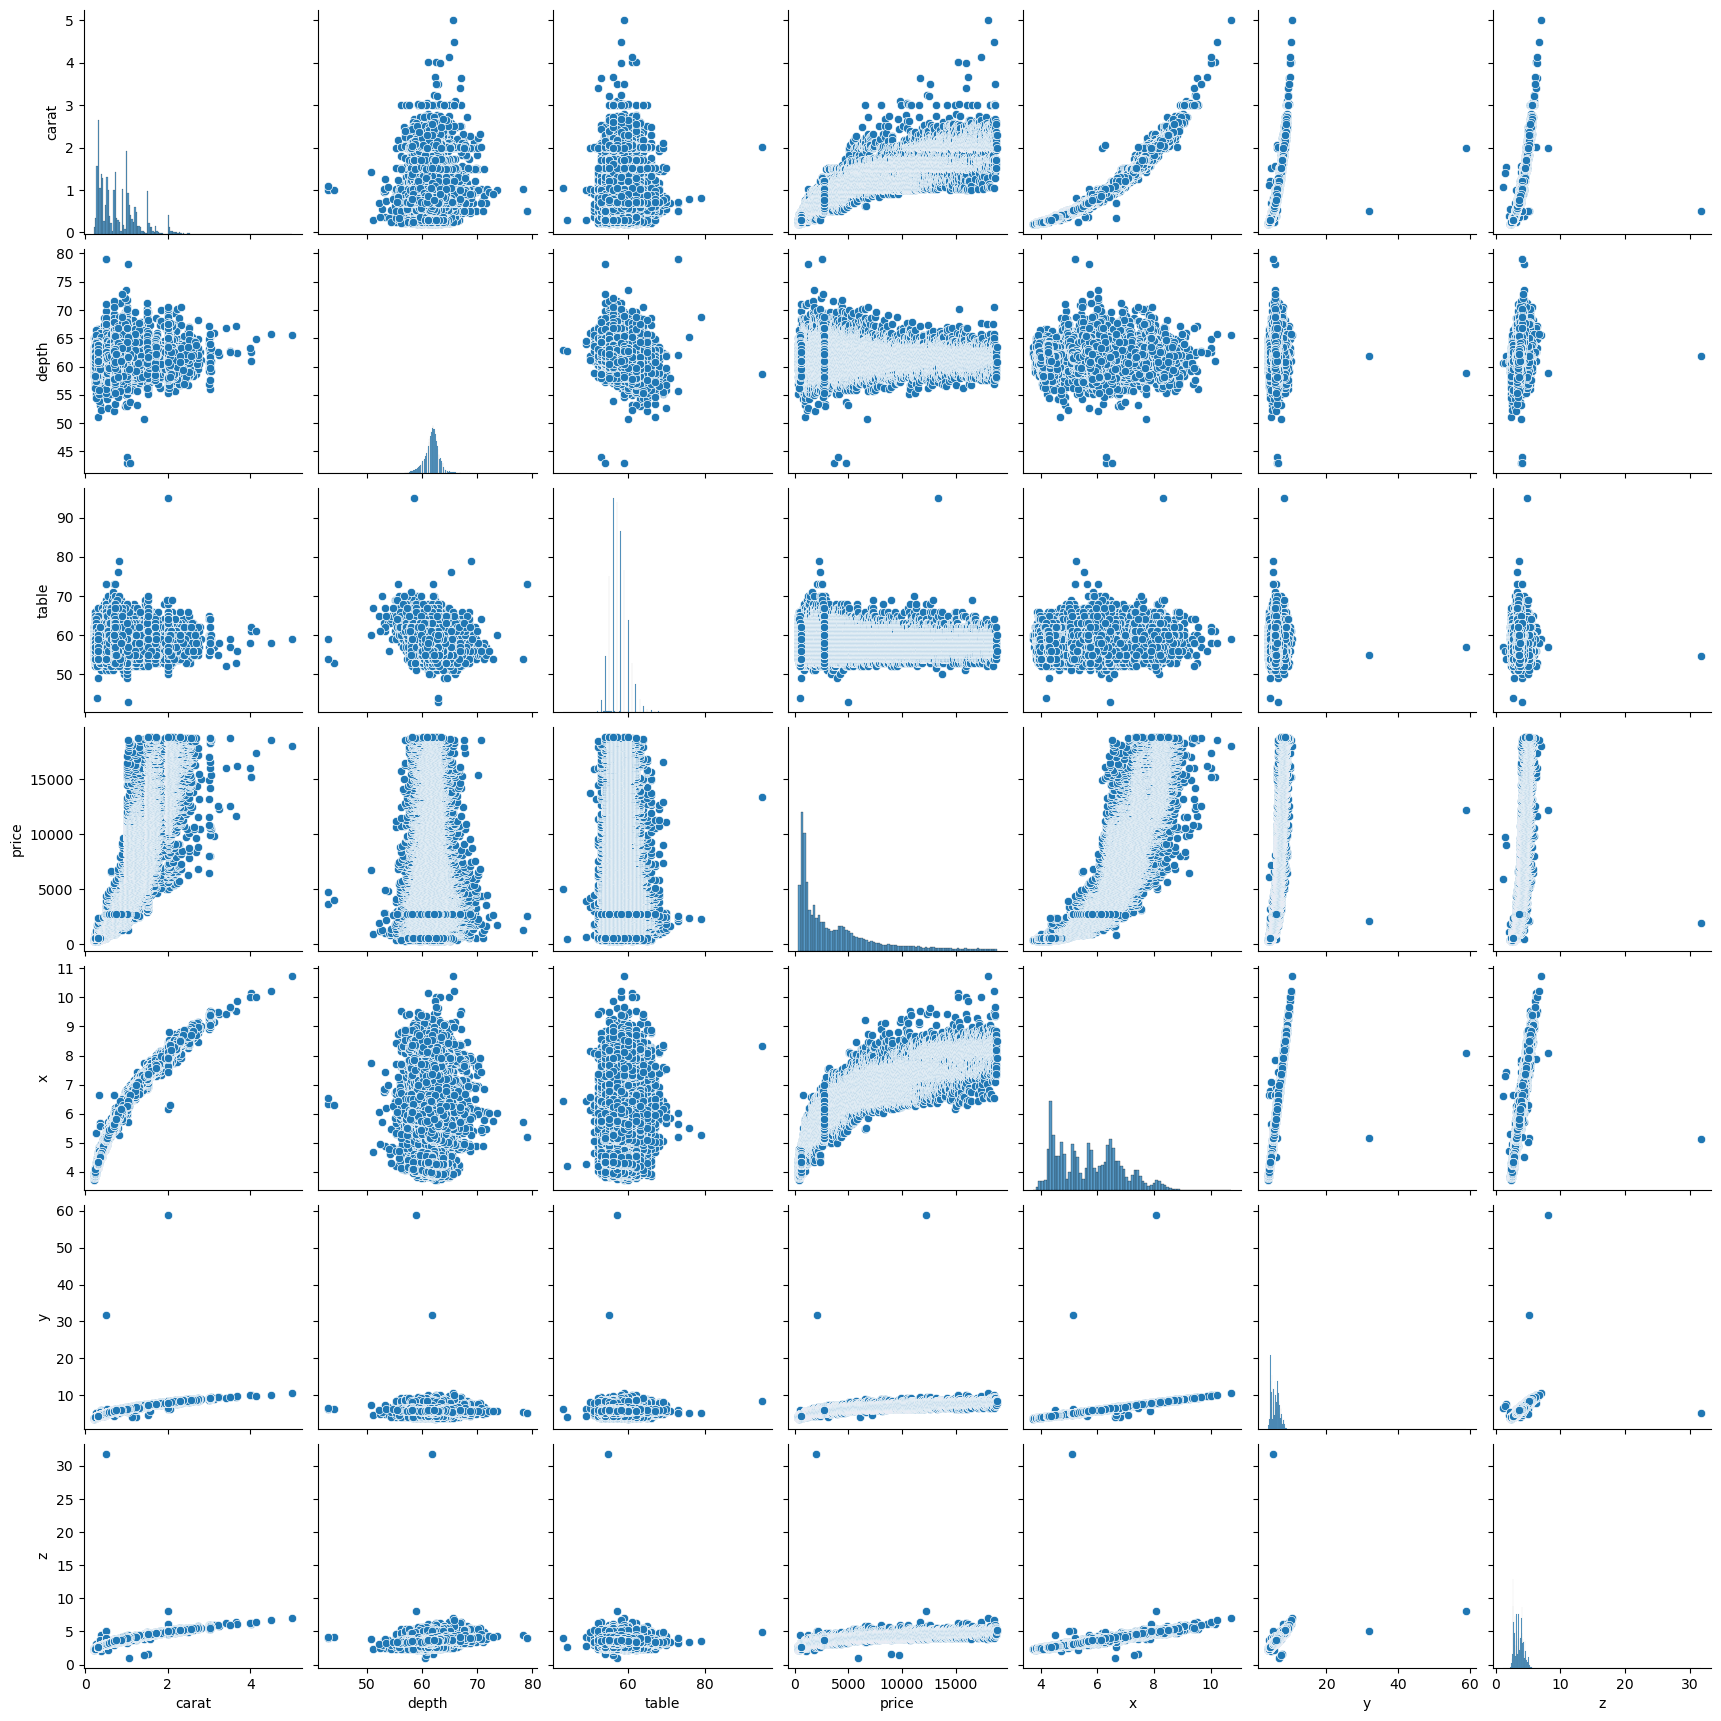

In [14]:
sns.pairplot(df)
plt.show()

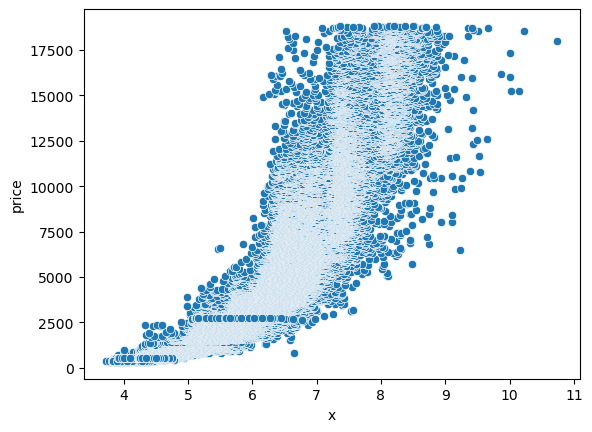

In [15]:
sns.scatterplot(x=df["x"],y=df["price"])
plt.show()

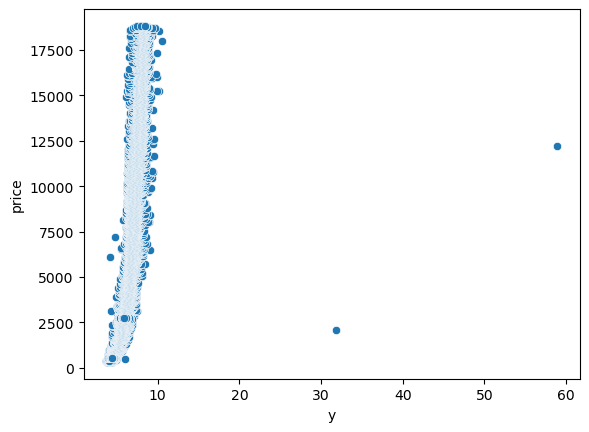

In [16]:
sns.scatterplot(x=df["y"],y=df["price"])
plt.show()

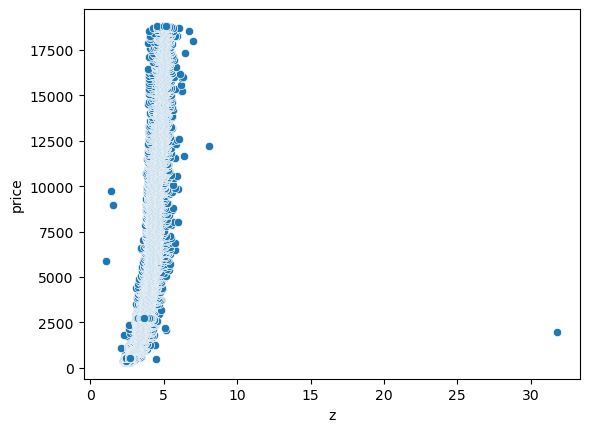

In [17]:
sns.scatterplot(x=df["z"],y=df["price"])
plt.show()

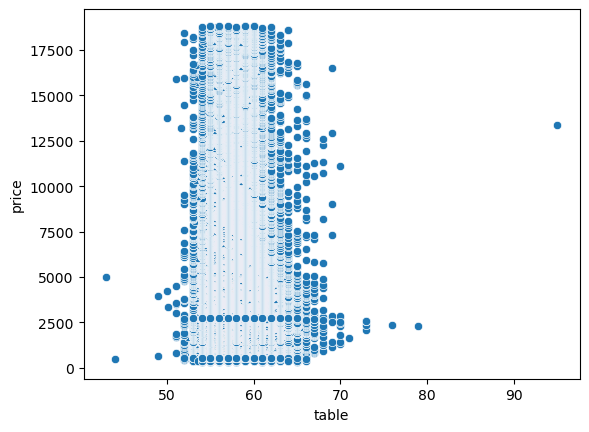

In [18]:
sns.scatterplot(x=df["table"],y=df["price"])
plt.show()

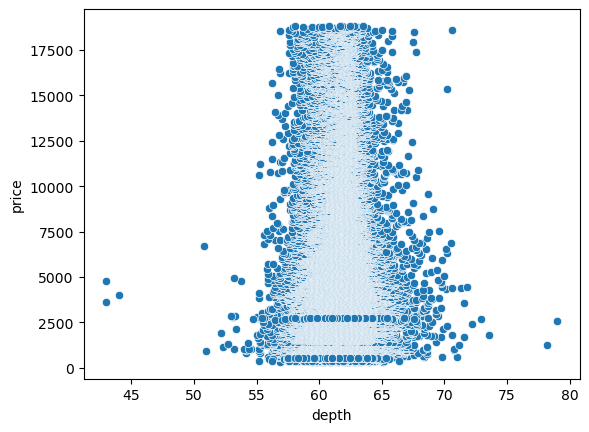

In [19]:
sns.scatterplot(x=df["depth"],y=df["price"])
plt.show()

In [20]:
df=df.drop(df[df["depth"]>75].index)
df=df.drop(df[df["depth"]<45].index)
df=df.drop(df[df["table"]>75].index)
df=df.drop(df[df["table"]<50].index)
df=df.drop(df[df["z"]>10].index)
df=df.drop(df[df["x"]>10].index)
df=df.drop(df[df["y"]>20].index)

In [21]:
df.shape

(53899, 10)

In [22]:
df["cut"].value_counts()

cut
Ideal        21545
Premium      13777
Very Good    12078
Good          4902
Fair          1597
Name: count, dtype: int64

In [23]:
df["color"].value_counts()

color
G    11281
E     9790
F     9536
H     8297
D     6774
I     5417
J     2804
Name: count, dtype: int64

In [24]:
df["clarity"].value_counts()

clarity
SI1     13059
VS2     12250
SI2      9183
VS1      8165
VVS2     5066
VVS1     3654
IF       1790
I1        732
Name: count, dtype: int64

In [25]:
X=df.drop("price", axis=1)
y=df["price"]

In [26]:
X.head()


,carat,cut,color,clarity,depth,table,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75


In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)


In [28]:
from sklearn.preprocessing import LabelEncoder
encoders = {}
for col in ["cut","color","clarity"]:
    encoders[col] = LabelEncoder()
    X_train[col] = encoders[col].fit_transform(X_train[col])
    X_test[col] = encoders[col].transform(X_test[col])

In [29]:
X_train.head()

,carat,cut,color,clarity,depth,table,x,y,z
2777,0.83,2,2,2,62.1,55.0,6.00,6.05,3.74
4250,0.78,1,1,2,59.4,62.0,6.02,6.07,3.59
24449,1.62,2,2,2,62.7,56.0,7.44,7.50,4.68
4850,0.71,2,2,4,61.4,56.0,5.75,5.78,3.54
33336,0.41,3,3,5,59.2,58.0,4.80,4.83,2.85


In [30]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [31]:
from sklearn.linear_model import LinearRegression
lr_model=LinearRegression()
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
lr_model.fit(X_train_scaled, y_train)
y_pred_lr=lr_model.predict(X_test_scaled)

print("Linear Regression Metrics:")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_lr))
print("R^2 Score:", r2_score(y_test, y_pred_lr))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_lr))


Linear Regression Metrics:
Mean Squared Error: 1767622.4663829624
R^2 Score: 0.8891370275583935
Mean Absolute Error: 858.1965768962688


In [32]:
from sklearn.svm import SVR
svm_model=SVR()
svm_model.fit(X_train_scaled, y_train)
y_pred_svm=svm_model.predict(X_test_scaled)
print("Support Vector Machine Metrics:")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_svm))
print("R^2 Score:", r2_score(y_test, y_pred_svm))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_svm))

Support Vector Machine Metrics:
Mean Squared Error: 8040380.159124441
R^2 Score: 0.4957178577702398
Mean Absolute Error: 1386.6816194512417


In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf', 'linear']
}
grid_search = GridSearchCV(SVR(), param_grid, cv=5)
grid_search.fit(X_train_scaled, y_train)
print("Best Parameters:", grid_search.best_params_)
best_svm = grid_search.best_estimator_
y_pred_best_svm = best_svm.predict(X_test_scaled)
print("Best SVM Metrics:")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_best_svm))
print("R^2 Score:", r2_score(y_test, y_pred_best_svm))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_best_svm))